# Una Convolución por Dentro

**Objetivo:** Reproducir manualmente el forward pass de una CNN, operación por operación, para entender qué ocurre dentro de cada capa.

La arquitectura que simulamos es equivalente a este modelo Keras:

```python
tf.keras.Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100,100,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(1, activation='sigmoid'),
])
```

> **Nota:** No se entrena ningún modelo. Los filtros son aleatorios para poder visualizar el flujo de información puro, sin sesgo de aprendizaje.

## 1. Importación de librerías

Usamos `OpenCV` para convolución, `scipy` para max pooling, `matplotlib` para visualización y `TensorFlow` solo para las capas densas finales.

In [ ]:
import cv2
import random
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
import tensorflow as tf

# Compatibilidad con Google Colab
try:
    from google.colab.patches import cv2_imshow
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

## 2. Carga y preparación de la imagen

Descargamos una imagen de prueba desde la web, la convertimos a escala de grises y la redimensionamos a **100×100 px** — el tamaño de entrada que espera el modelo.

> Podés reemplazar `URL_IMAGEN` con cualquier URL de imagen accesible públicamente.

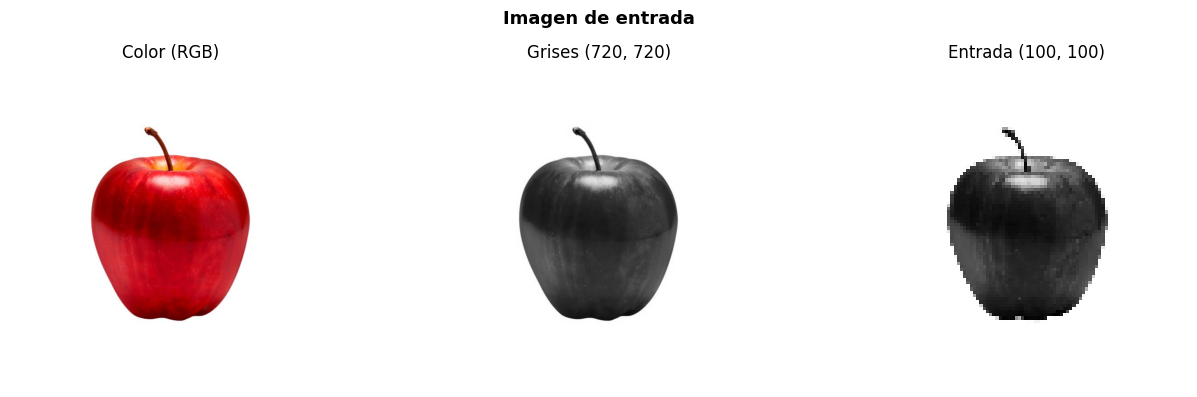

In [ ]:
# ── PLACEHOLDER: reemplazá esta URL por la imagen que quieras ──────────────
URL_IMAGEN = "https://images.rappi.com.ar/products/1764819033719_dd1ebb3e-89f5-4b03-8519-aa2145873a78_MANZNA-ROJA.jpg"
# ────────────────────────────────────────────────────────────────────────────

resp       = urllib.request.urlopen(URL_IMAGEN)
imagen_np  = np.asarray(bytearray(resp.read()), dtype=np.uint8)
imagen     = cv2.imdecode(imagen_np, cv2.IMREAD_COLOR)

imagen_color = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
imagen_gris  = cv2.cvtColor(imagen_color, cv2.COLOR_RGB2GRAY)

# Redimensionado a 100×100
ANCHO, ALTO = 100, 100
imagen_entrada = cv2.resize(imagen_gris, (ANCHO, ALTO))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(imagen_color);                    axes[0].set_title("Color (RGB)");              axes[0].axis("off")
axes[1].imshow(imagen_gris,  cmap="gray");       axes[1].set_title(f"Grises {imagen_gris.shape}");  axes[1].axis("off")
axes[2].imshow(imagen_entrada, cmap="gray");     axes[2].set_title(f"Entrada {imagen_entrada.shape}"); axes[2].axis("off")
plt.suptitle("Imagen de entrada", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Función auxiliar: Max Pooling 2×2

Definimos la función de pooling una sola vez para reutilizarla en todas las capas.

Toma el valor máximo en ventanas de 2×2 con stride 2, reduciendo cada mapa a la mitad en cada dimensión.

In [ ]:
def max_pooling_2x2(mapa):
    """Max pooling 2×2 con stride 2 — equivalente a tf.keras.layers.MaxPooling2D(2,2)."""
    return maximum_filter(mapa, size=2)[::2, ::2]

## 4. Capa 1 — Convolución

Generamos **32 filtros aleatorios de 3×3** y los aplicamos a la imagen de entrada.  
Después de la convolución aplicamos **ReLU** (`max(0, x)`), que elimina activaciones negativas y añade no-linealidad.

> En un modelo entrenado estos filtros no serían aleatorios: serían los pesos aprendidos por backpropagation. Aquí son aleatorios para poder ver la mecánica pura.

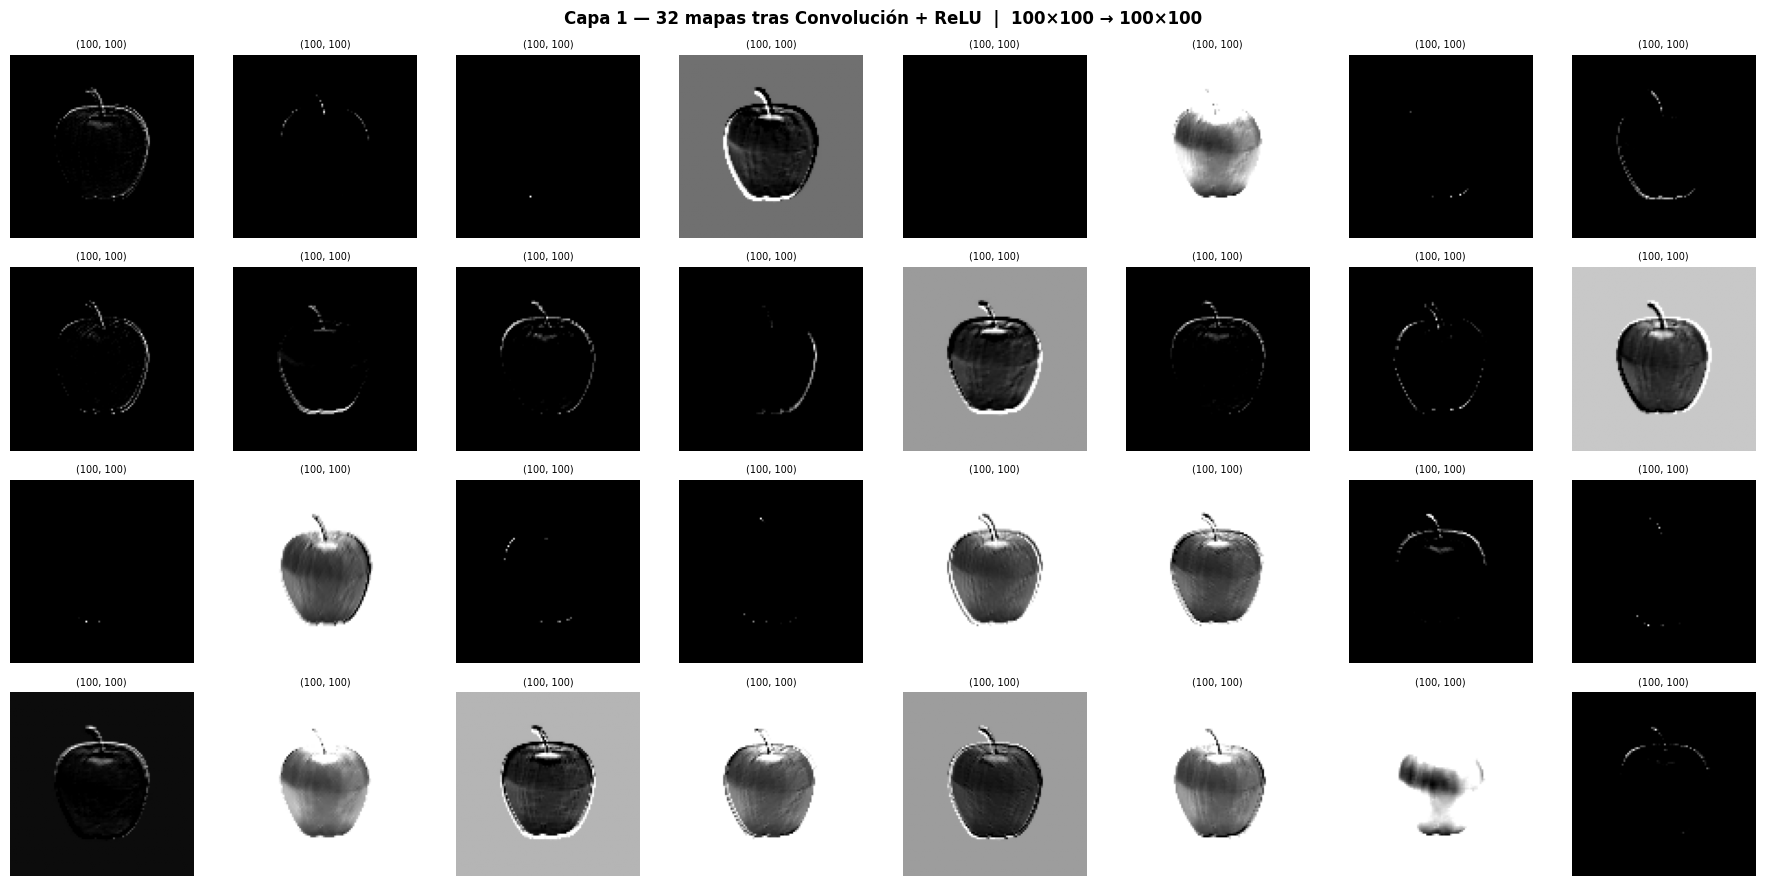

Mapas: 32  |  Forma: (100, 100)


In [ ]:
np.random.seed(42)
filtros_capa1 = [np.random.uniform(-1, 1, (3, 3)) for _ in range(32)]

mapas_1_conv = []
for filtro in filtros_capa1:
    conv  = cv2.filter2D(imagen_entrada, -1, filtro)
    relu  = np.maximum(0, conv)          # Activación ReLU
    mapas_1_conv.append(relu)

# Visualización — los 32 mapas tras Conv + ReLU
fig, axes = plt.subplots(4, 8, figsize=(18, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(mapas_1_conv[i], cmap="gray")
    ax.set_title(f"{mapas_1_conv[i].shape}", fontsize=7)
    ax.axis("off")
plt.suptitle("Capa 1 — 32 mapas tras Convolución + ReLU  |  100×100 → 100×100", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Mapas: {len(mapas_1_conv)}  |  Forma: {mapas_1_conv[0].shape}")

## 5. Capa 1 — Max Pooling

Reducimos cada uno de los 32 mapas a la mitad aplicando max pooling 2×2.  
El pooling descarta información espacial de baja importancia y hace la red más robusta a pequeñas traslaciones.

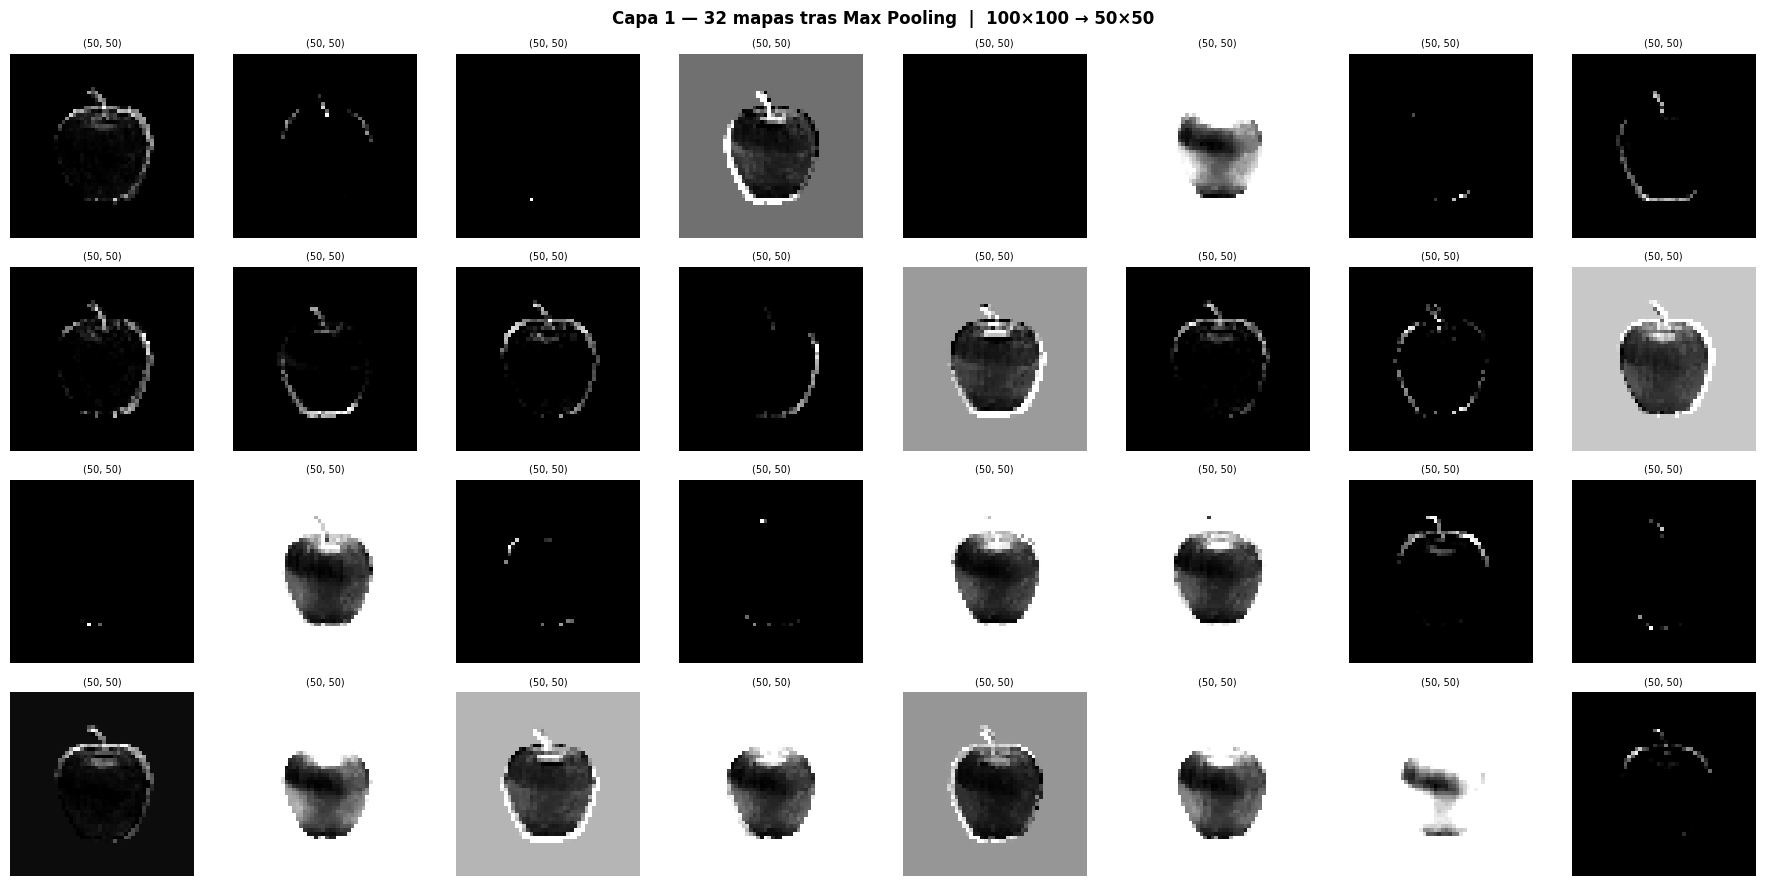

Mapas: 32  |  Forma: (50, 50)


In [ ]:
mapas_1_pool = [max_pooling_2x2(m) for m in mapas_1_conv]

fig, axes = plt.subplots(4, 8, figsize=(18, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(mapas_1_pool[i], cmap="gray")
    ax.set_title(f"{mapas_1_pool[i].shape}", fontsize=7)
    ax.axis("off")
plt.suptitle("Capa 1 — 32 mapas tras Max Pooling  |  100×100 → 50×50", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Mapas: {len(mapas_1_pool)}  |  Forma: {mapas_1_pool[0].shape}")

### Evolución hasta Capa 1

Comparamos la imagen original con el resultado después de conv y después de pooling para un filtro al azar.

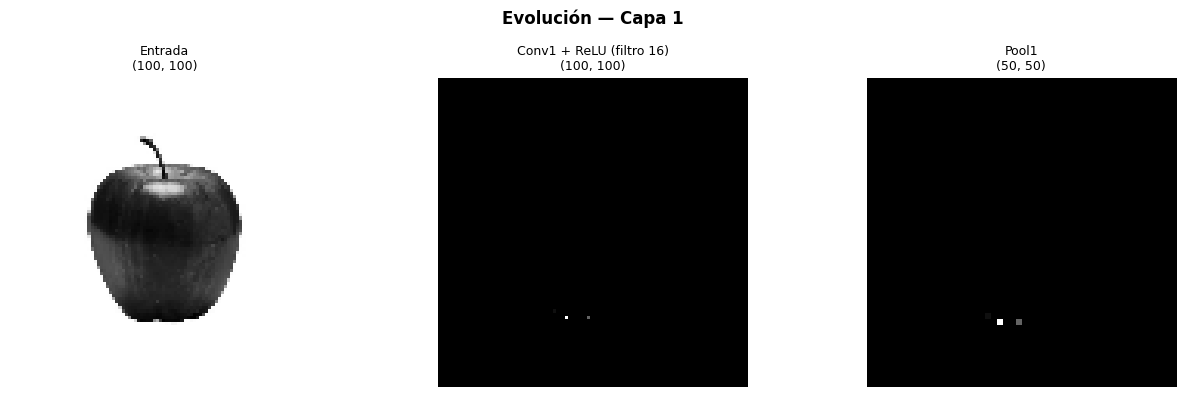

In [ ]:
idx = random.randint(0, 31)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
datos = [
    (imagen_entrada,    f"Entrada\n{imagen_entrada.shape}"),
    (mapas_1_conv[idx], f"Conv1 + ReLU (filtro {idx})\n{mapas_1_conv[idx].shape}"),
    (mapas_1_pool[idx], f"Pool1\n{mapas_1_pool[idx].shape}"),
]
for ax, (img, titulo) in zip(axes, datos):
    ax.imshow(img, cmap="gray"); ax.set_title(titulo, fontsize=9); ax.axis("off")
plt.suptitle("Evolución — Capa 1", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 6. Capa 2 — Convolución

Generamos **64 filtros de 3×3**. Cada filtro se aplica a los **32 mapas** de la capa anterior y sus respuestas se suman para producir **un único mapa por filtro**.

Esta suma es exactamente cómo `Conv2D` maneja múltiples canales de entrada: cada canal tiene su propio kernel, y los resultados se acumulan.

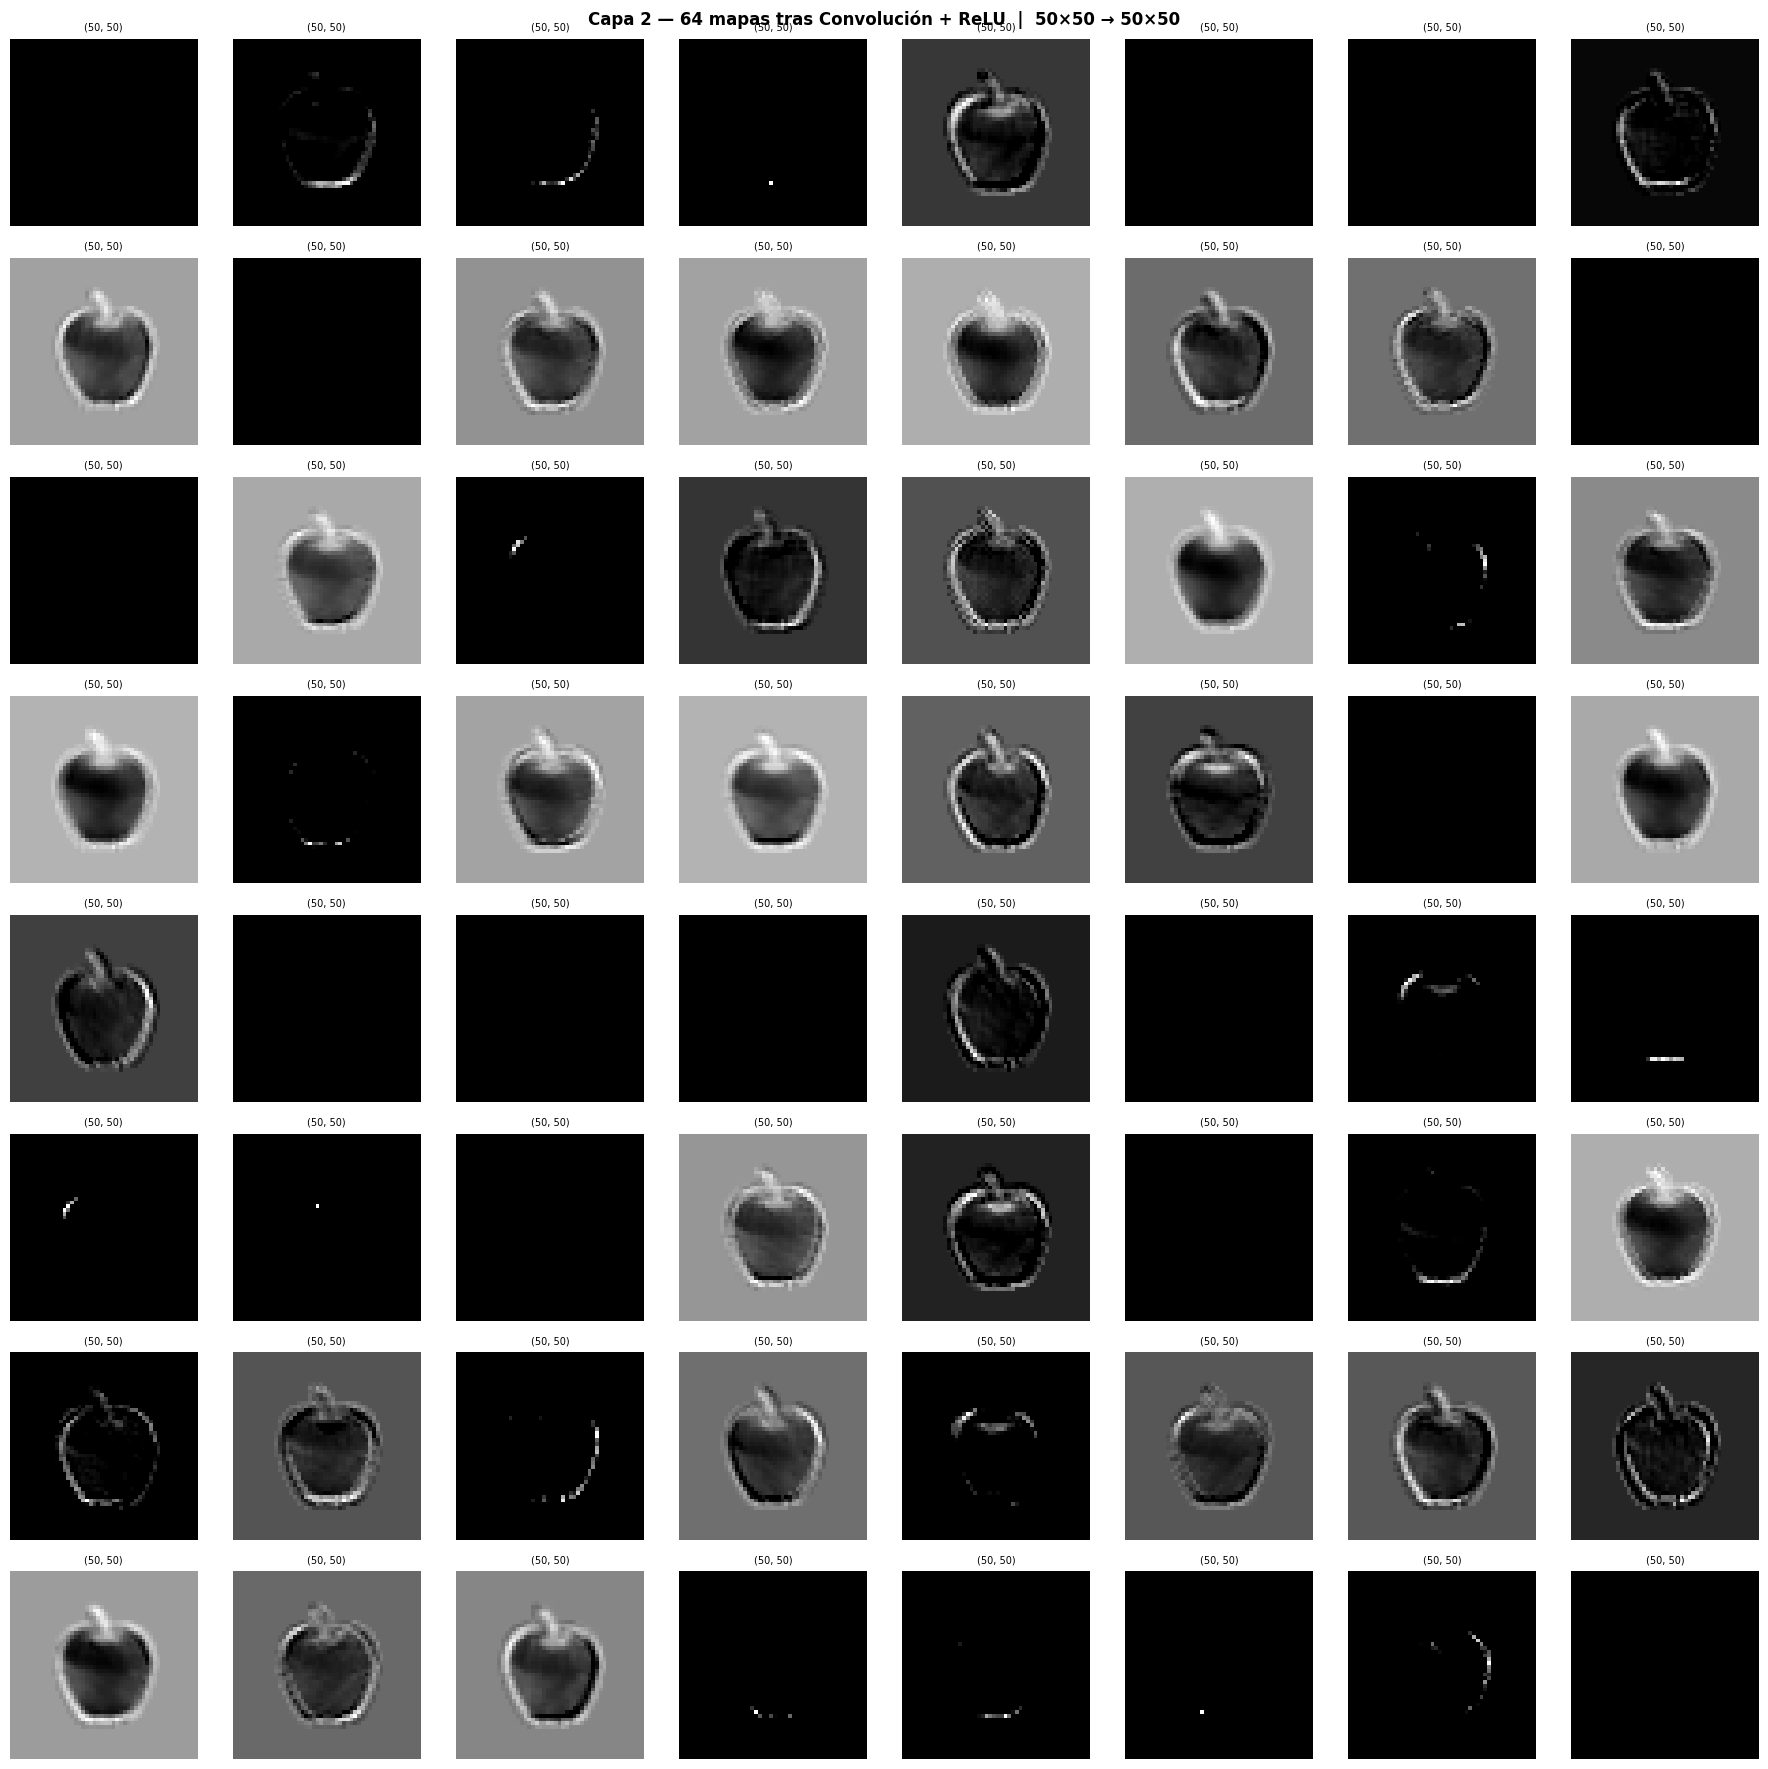

Mapas: 64  |  Forma: (50, 50)


In [ ]:
filtros_capa2 = [np.random.uniform(-1, 1, (3, 3)).astype(np.float32) for _ in range(64)]

mapas_2_conv = []
for filtro in filtros_capa2:
    respuestas = [cv2.filter2D(m.astype(np.float32), -1, filtro) for m in mapas_1_pool]
    combinado  = np.sum(respuestas, axis=0)   # fusión de los 32 canales
    relu       = np.maximum(0, combinado)
    mapas_2_conv.append(relu)

fig, axes = plt.subplots(8, 8, figsize=(18, 18))
for i, ax in enumerate(axes.flat):
    ax.imshow(mapas_2_conv[i], cmap="gray")
    ax.set_title(f"{mapas_2_conv[i].shape}", fontsize=7)
    ax.axis("off")
plt.suptitle("Capa 2 — 64 mapas tras Convolución + ReLU  |  50×50 → 50×50", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Mapas: {len(mapas_2_conv)}  |  Forma: {mapas_2_conv[0].shape}")

## 7. Capa 2 — Max Pooling

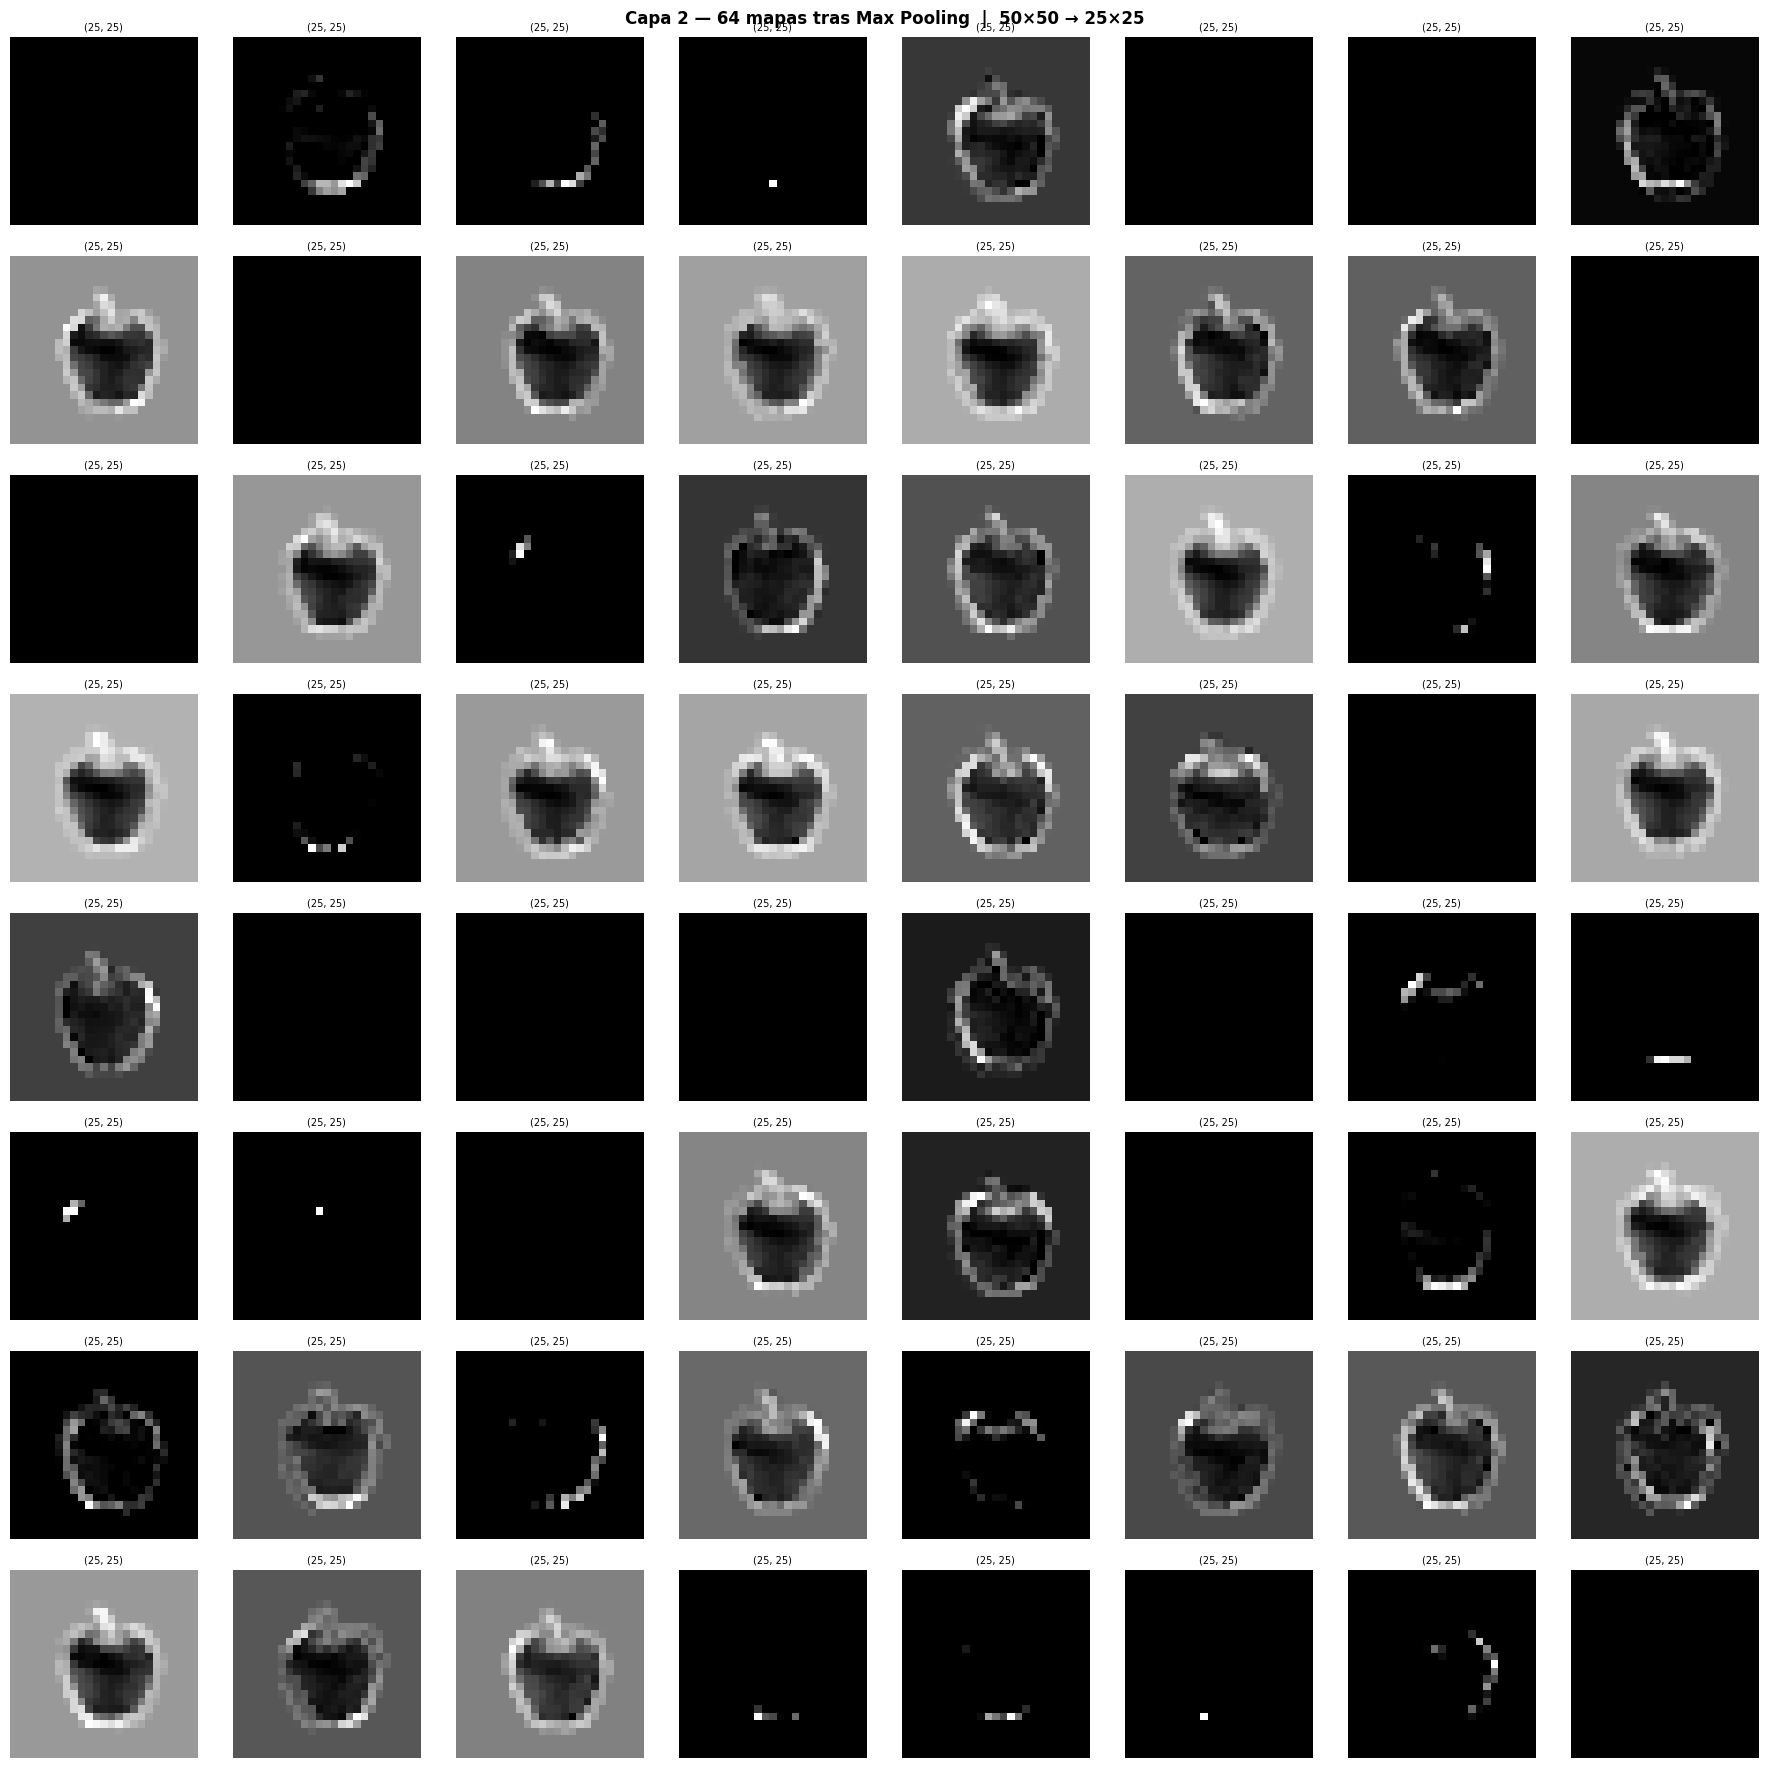

Mapas: 64  |  Forma: (25, 25)


In [ ]:
mapas_2_pool = [max_pooling_2x2(m) for m in mapas_2_conv]

fig, axes = plt.subplots(8, 8, figsize=(18, 18))
for i, ax in enumerate(axes.flat):
    ax.imshow(mapas_2_pool[i], cmap="gray")
    ax.set_title(f"{mapas_2_pool[i].shape}", fontsize=7)
    ax.axis("off")
plt.suptitle("Capa 2 — 64 mapas tras Max Pooling  |  50×50 → 25×25", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Mapas: {len(mapas_2_pool)}  |  Forma: {mapas_2_pool[0].shape}")

### Evolución hasta Capa 2

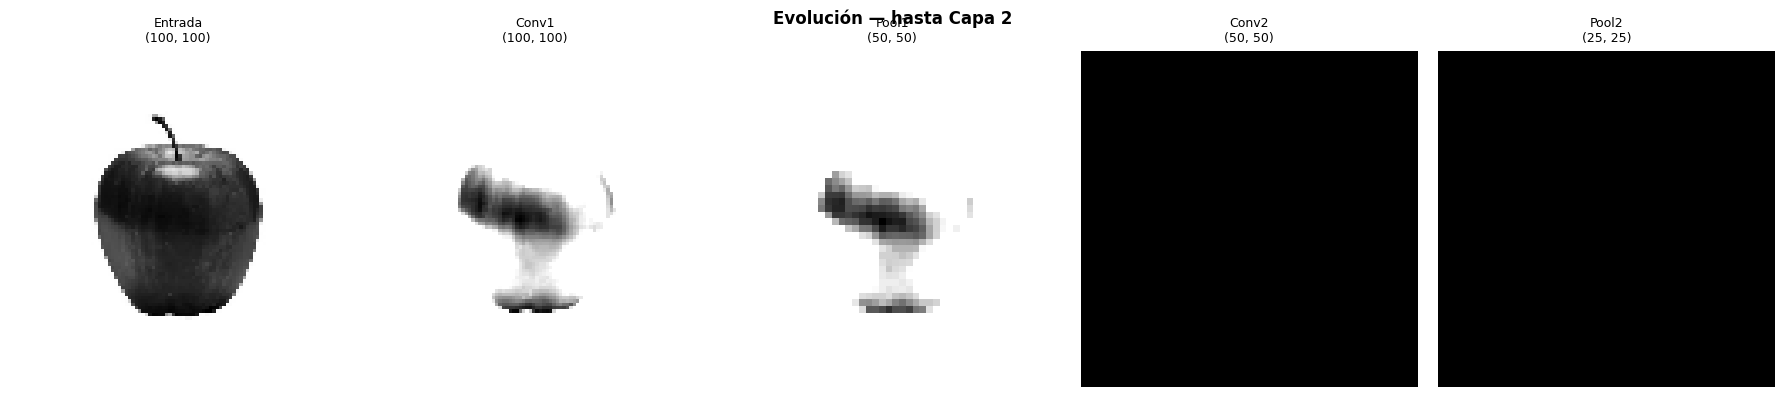

In [ ]:
idx = random.randint(0, 31)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
datos = [
    (imagen_entrada,    f"Entrada\n{imagen_entrada.shape}"),
    (mapas_1_conv[idx], f"Conv1\n{mapas_1_conv[idx].shape}"),
    (mapas_1_pool[idx], f"Pool1\n{mapas_1_pool[idx].shape}"),
    (mapas_2_conv[idx], f"Conv2\n{mapas_2_conv[idx].shape}"),
    (mapas_2_pool[idx], f"Pool2\n{mapas_2_pool[idx].shape}"),
]
for ax, (img, titulo) in zip(axes, datos):
    ax.imshow(img, cmap="gray"); ax.set_title(titulo, fontsize=9); ax.axis("off")
plt.suptitle("Evolución — hasta Capa 2", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 8. Capa 3 — Convolución

**128 filtros** aplicados a los 64 mapas de la capa anterior. A esta altura cada mapa es de ≈12×12 px — la red ya extrajo características cada vez más abstractas y de alto nivel.

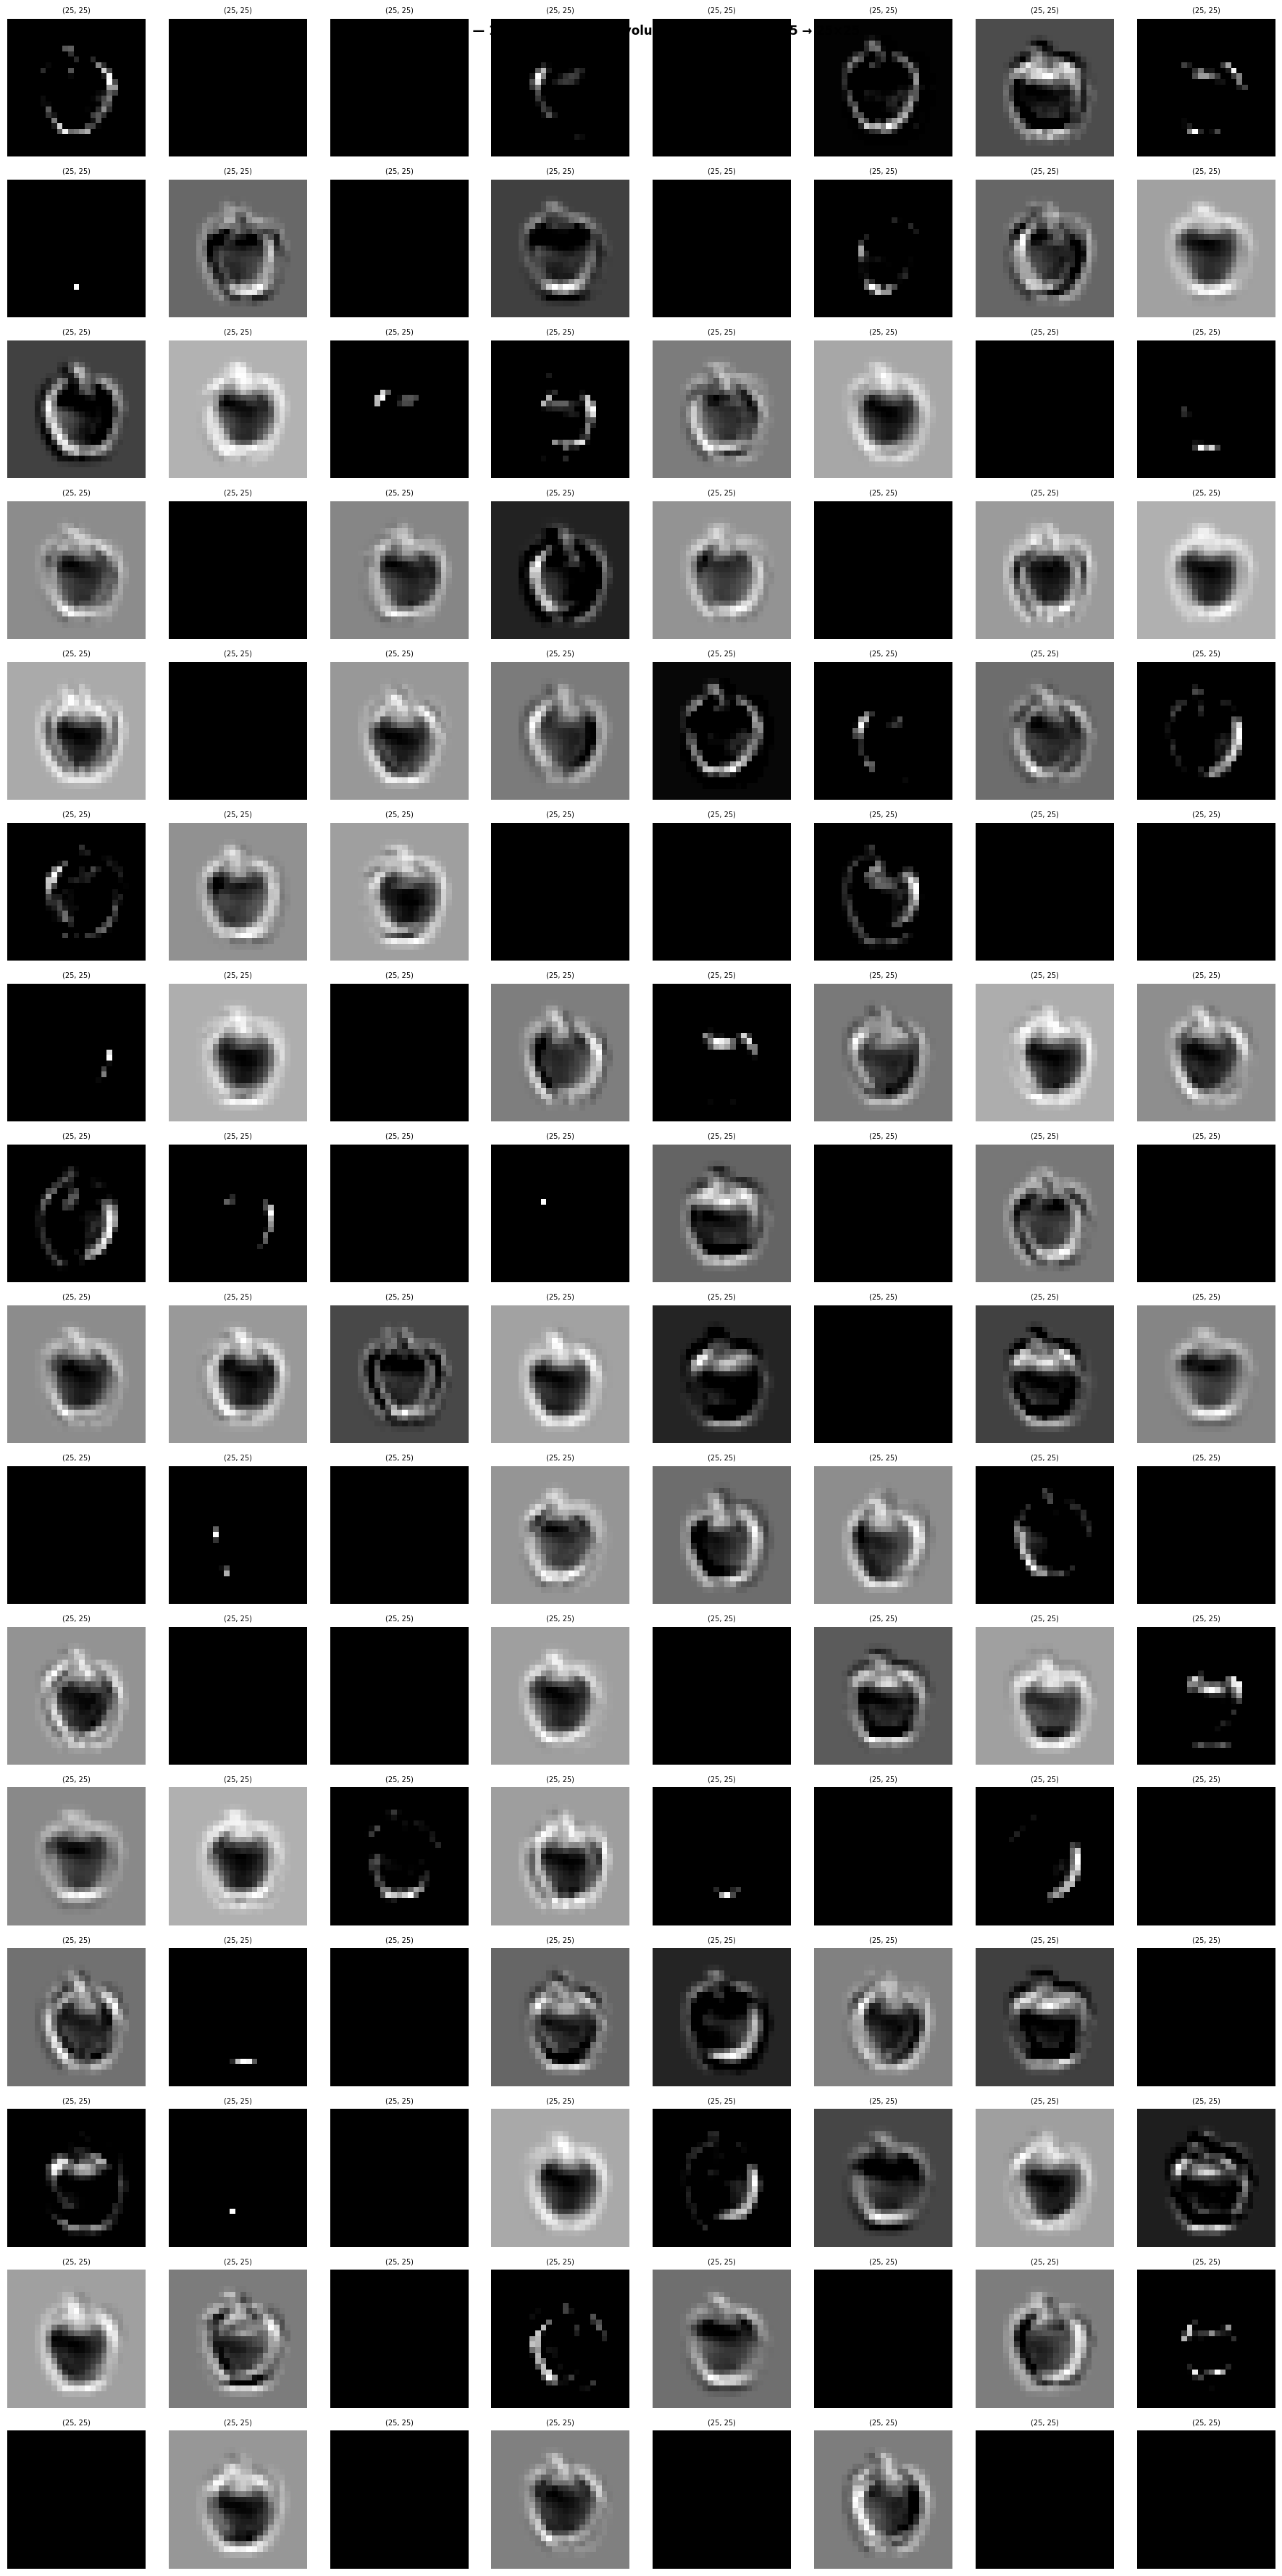

Mapas: 128  |  Forma: (25, 25)


In [ ]:
filtros_capa3 = [np.random.uniform(-1, 1, (3, 3)).astype(np.float32) for _ in range(128)]

mapas_3_conv = []
for filtro in filtros_capa3:
    respuestas = [cv2.filter2D(m.astype(np.float32), -1, filtro) for m in mapas_2_pool]
    combinado  = np.sum(respuestas, axis=0)
    relu       = np.maximum(0, combinado)
    mapas_3_conv.append(relu)

fig, axes = plt.subplots(16, 8, figsize=(18, 36))
for i, ax in enumerate(axes.flat):
    ax.imshow(mapas_3_conv[i], cmap="gray")
    ax.set_title(f"{mapas_3_conv[i].shape}", fontsize=7)
    ax.axis("off")
plt.suptitle("Capa 3 — 128 mapas tras Convolución + ReLU  |  25×25 → 25×25", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Mapas: {len(mapas_3_conv)}  |  Forma: {mapas_3_conv[0].shape}")

## 9. Capa 3 — Max Pooling

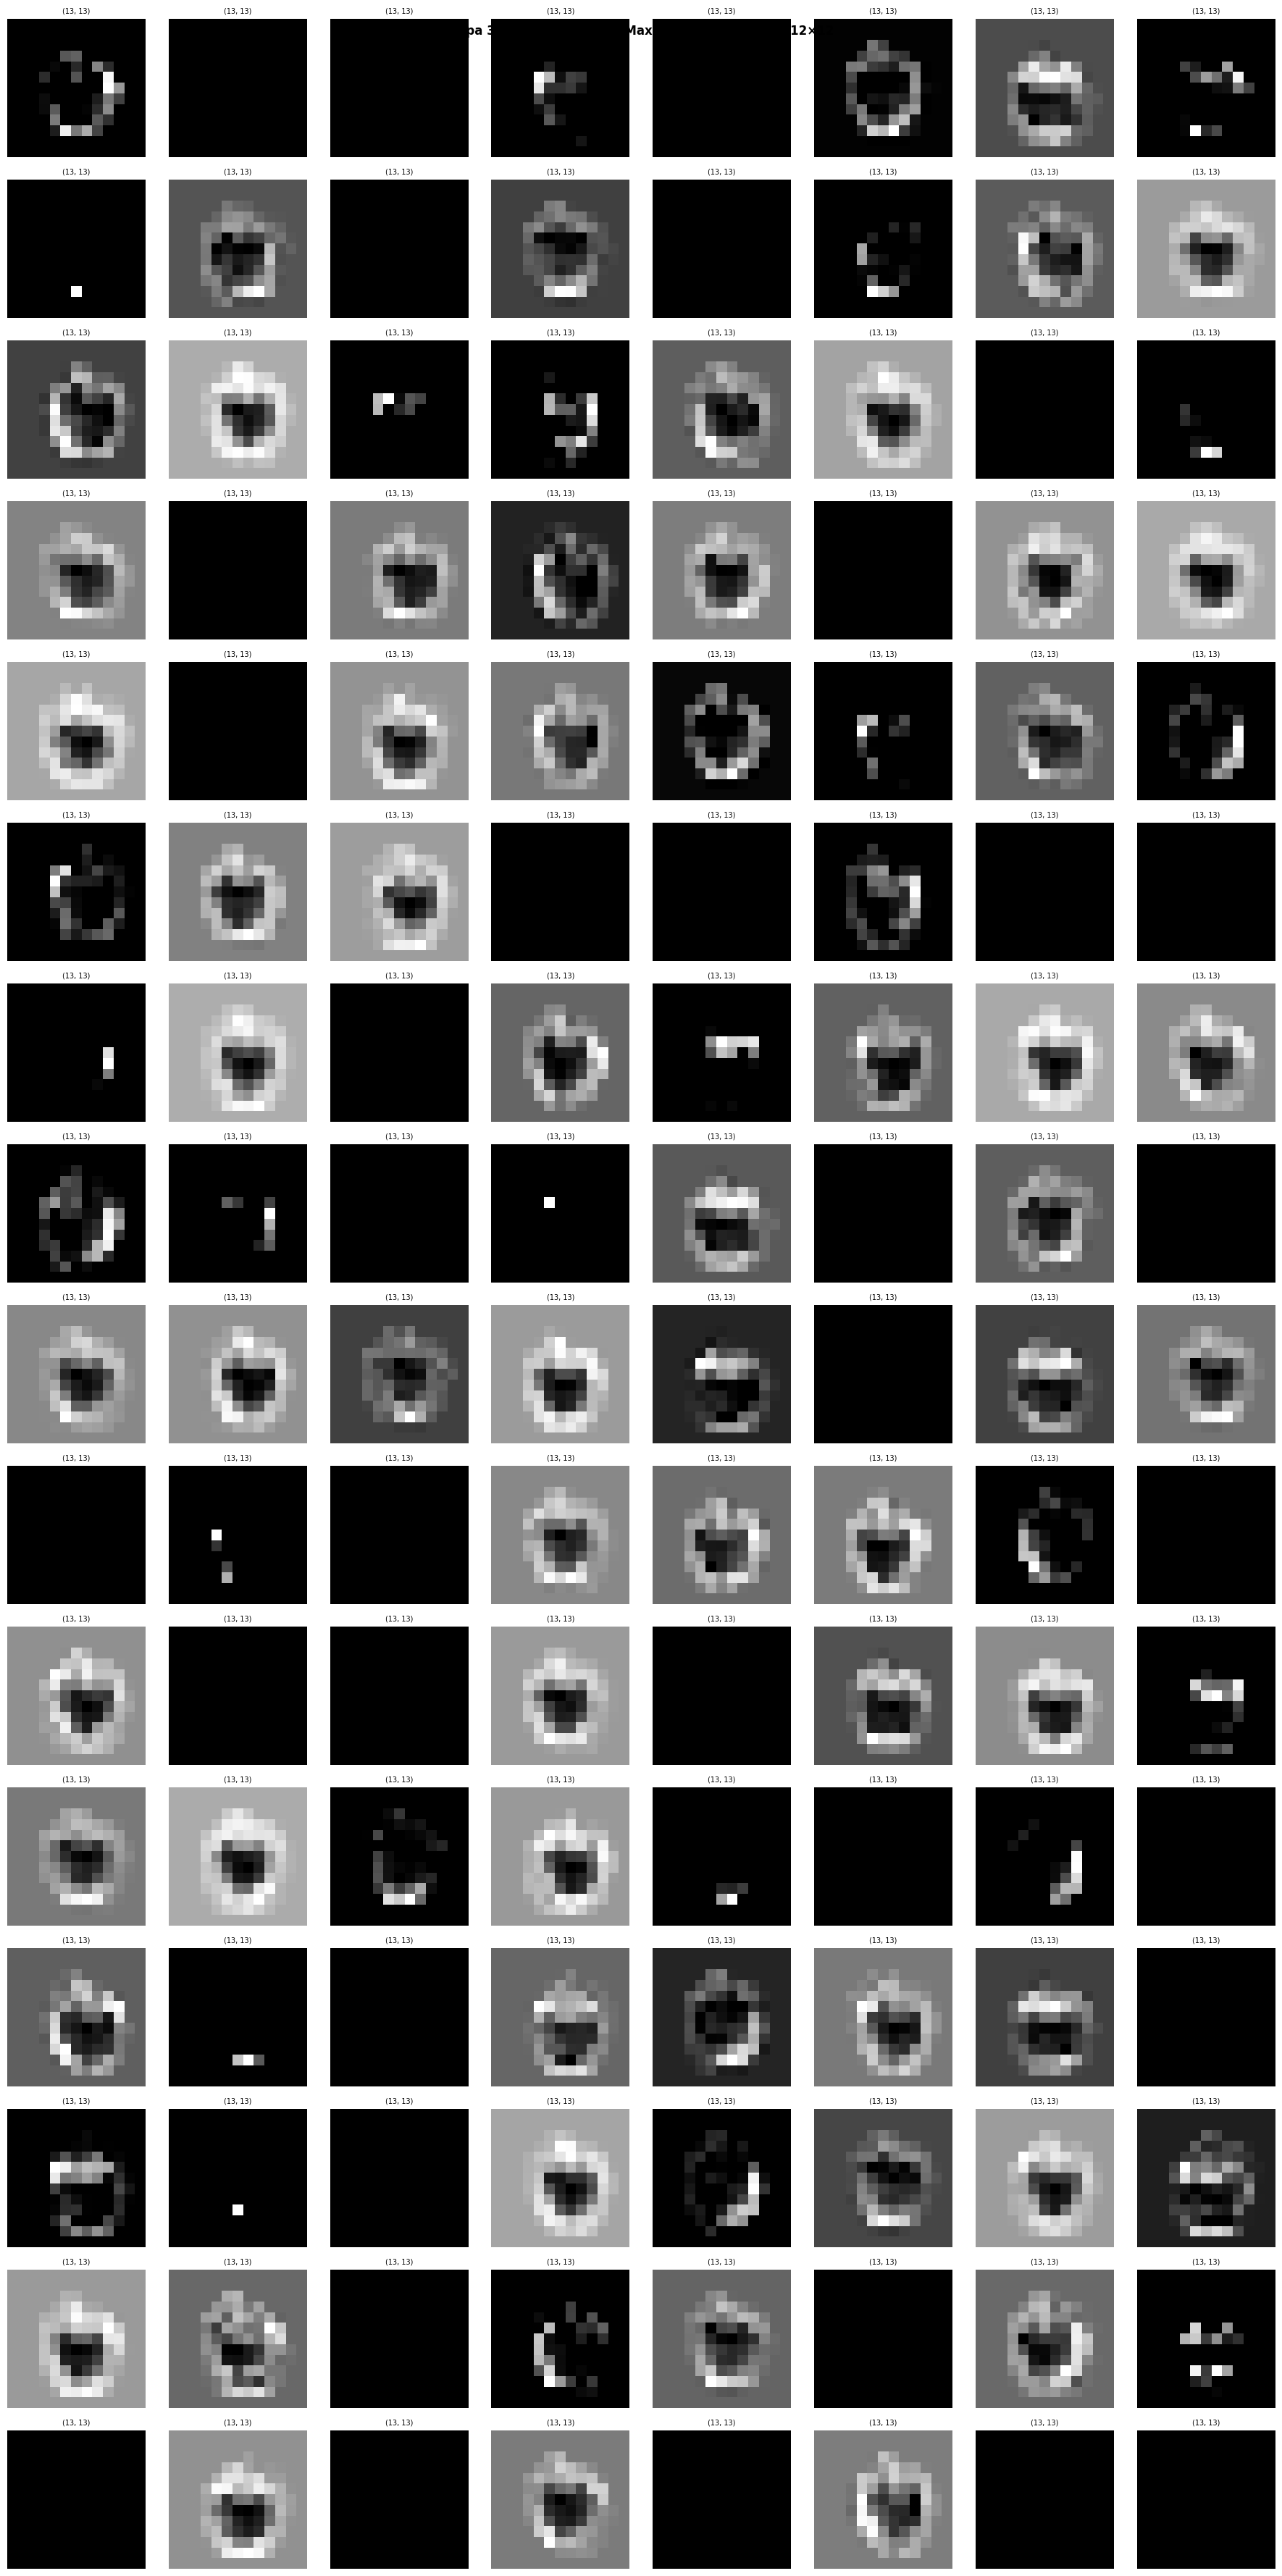

Mapas: 128  |  Forma: (13, 13)


In [ ]:
mapas_3_pool = [max_pooling_2x2(m) for m in mapas_3_conv]

fig, axes = plt.subplots(16, 8, figsize=(18, 36))
for i, ax in enumerate(axes.flat):
    ax.imshow(mapas_3_pool[i], cmap="gray")
    ax.set_title(f"{mapas_3_pool[i].shape}", fontsize=7)
    ax.axis("off")
plt.suptitle("Capa 3 — 128 mapas tras Max Pooling  |  25×25 → 12×12", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Mapas: {len(mapas_3_pool)}  |  Forma: {mapas_3_pool[0].shape}")

### Evolución completa del pipeline

Seleccionamos un filtro al azar y mostramos todas las etapas de transformación de la imagen.

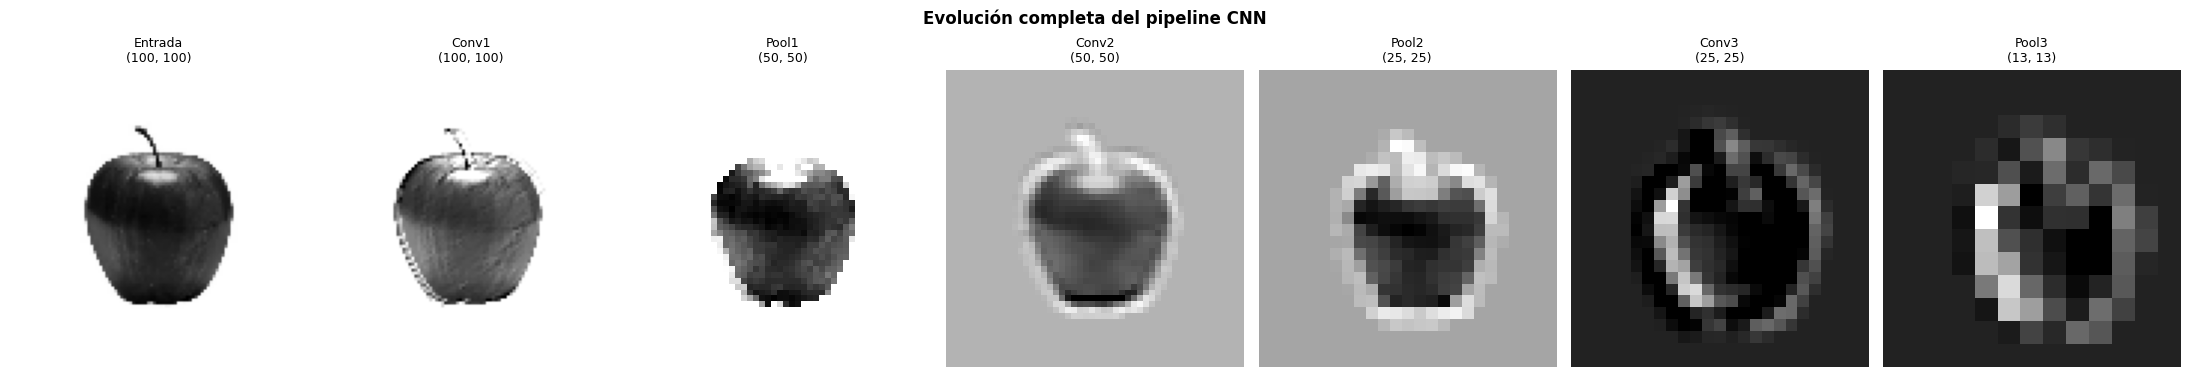

In [ ]:
idx = random.randint(0, 31)
fig, axes = plt.subplots(1, 7, figsize=(22, 4))
datos = [
    (imagen_entrada,    f"Entrada\n{imagen_entrada.shape}"),
    (mapas_1_conv[idx], f"Conv1\n{mapas_1_conv[idx].shape}"),
    (mapas_1_pool[idx], f"Pool1\n{mapas_1_pool[idx].shape}"),
    (mapas_2_conv[idx], f"Conv2\n{mapas_2_conv[idx].shape}"),
    (mapas_2_pool[idx], f"Pool2\n{mapas_2_pool[idx].shape}"),
    (mapas_3_conv[idx], f"Conv3\n{mapas_3_conv[idx].shape}"),
    (mapas_3_pool[idx], f"Pool3\n{mapas_3_pool[idx].shape}"),
]
for ax, (img, titulo) in zip(axes, datos):
    ax.imshow(img, cmap="gray"); ax.set_title(titulo, fontsize=9); ax.axis("off")
plt.suptitle("Evolución completa del pipeline CNN", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 10. Flatten

Los 128 mapas de ≈12×12 se convierten en un único vector 1D.  
Esta operación no aprende nada — simplemente reorganiza los datos para que la capa densa pueda procesarlos como un vector de características.

In [ ]:
vector_flatten = np.array(mapas_3_pool).ravel()

forma_mapa = mapas_3_pool[0].shape
print(f"Mapas:          128")
print(f"Forma de cada:  {forma_mapa}")
print(f"Vector flatten: {vector_flatten.shape}  ({128} × {forma_mapa[0]} × {forma_mapa[1]} = {128 * forma_mapa[0] * forma_mapa[1]})")

Mapas:          128
Forma de cada:  (13, 13)
Vector flatten: (21632,)  (128 × 13 × 13 = 21632)


## 11. Capas Dense — predicción final

El vector flatten alimenta dos capas densas:
- **Dense(100, ReLU):** combina linealmente todas las características extraídas.
- **Dense(1, Sigmoid):** comprime la salida a `[0, 1]`, interpretable como probabilidad de clase.

> El valor que se imprime es aleatorio porque los pesos no fueron entrenados. En un modelo real representaría la probabilidad de que la imagen pertenezca a la clase positiva.

In [ ]:
capa_densa  = tf.keras.layers.Dense(100, activation='relu')
capa_salida = tf.keras.layers.Dense(1,   activation='sigmoid')

entrada_tf   = tf.convert_to_tensor(vector_flatten.reshape(1, -1), dtype=tf.float32)
salida_densa = capa_densa(entrada_tf)
prediccion   = capa_salida(salida_densa)

print(f"Salida Dense(100): {salida_densa.shape}")
print(f"Predicción final:  {prediccion.numpy()[0][0]:.6f}  (valor aleatorio — pesos sin entrenar)")

Salida Dense(100): (1, 100)
Predicción final:  1.000000  (valor aleatorio — pesos sin entrenar)


## 12. Resumen del pipeline

| Operación | Entrada | Salida |
|---|---|---|
| Conv2D(32) + ReLU | 100×100 | 32 mapas 100×100 |
| MaxPooling2D(2,2) | 32 × 100×100 | 32 mapas 50×50 |
| Conv2D(64) + ReLU | 32 × 50×50 | 64 mapas 50×50 |
| MaxPooling2D(2,2) | 64 × 50×50 | 64 mapas 25×25 |
| Conv2D(128) + ReLU | 64 × 25×25 | 128 mapas 25×25 |
| MaxPooling2D(2,2) | 128 × 25×25 | 128 mapas 12×12 |
| Flatten | 128 × 12×12 | vector 1D |
| Dense(100) + Dense(1) | vector 1D | escalar ∈ [0, 1] |

**Lo que no se muestra aquí** es el backpropagation: el proceso por el cual los filtros se ajustan para minimizar el error. Eso ocurre durante el entrenamiento en `modeloCNN.ipynb`.